Assignment 2: Image Segmentation with Different CNN Architectures
> Train and compare at least two different CNN-based segmentation models (Simple FCN and a small U-Net-like model) on an image+mask dataset, and visualize their results.





In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
class COCOSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, img_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.img_size = img_size

        # Get all image files
        self.images = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
        print(f"Found {len(self.images)} images in {image_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')

        # Get corresponding mask
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(self.mask_dir, img_name.replace('.jpg', '_mask.png'))

        # Load mask (if exists, else create empty mask)
        if os.path.exists(mask_path):
            mask = Image.open(mask_path).convert('L')  # Grayscale
        else:
            mask = Image.new('L', image.size, 0)

        # Resize
        image = image.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        # Convert to tensor
        image = transforms.ToTensor()(image)
        mask = torch.from_numpy(np.array(mask)).float()

        # Normalize mask to 0-1
        mask = (mask > 0).float()

        return image, mask.unsqueeze(0)

In [5]:
class SimpleFCN(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SimpleFCN, self).__init__()

        # Encoder (downsampling)
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        # Decoder (upsampling) - FIXED: 3 upsampling layers only
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = self.conv_block(256, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(128, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = self.conv_block(64, 64)

        # Final output (no extra upsampling)
        self.out = nn.Conv2d(64, out_channels, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)           # 256x256
        e2 = self.enc2(self.pool(e1))  # 128x128
        e3 = self.enc3(self.pool(e2))  # 64x64
        e4 = self.enc4(self.pool(e3))  # 32x32

        # Decoder
        d1 = self.dec1(self.up1(e4))  # 64x64
        d2 = self.dec2(self.up2(d1))  # 128x128
        d3 = self.dec3(self.up3(d2))  # 256x256

        # Output
        out = self.out(d3)  # 256x256
        return torch.sigmoid(out)

In [6]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SimpleUNet, self).__init__()

        # Encoder (downsampling with skip connections)
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        # Decoder (upsampling with skip connections) - FIXED
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = self.conv_block(512, 256)  # 256 + 256 from skip

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(256, 128)  # 128 + 128 from skip

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = self.conv_block(128, 64)   # 64 + 64 from skip

        # Final output (no extra upsampling)
        self.out = nn.Conv2d(64, out_channels, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder with skip connections
        e1 = self.enc1(x)              # 256x256
        e2 = self.enc2(self.pool(e1))  # 128x128
        e3 = self.enc3(self.pool(e2))  # 64x64
        e4 = self.enc4(self.pool(e3))  # 32x32

        # Decoder with skip connections
        d1 = self.up1(e4)              # 64x64
        d1 = torch.cat([d1, e3], dim=1)  # Skip connection
        d1 = self.dec1(d1)

        d2 = self.up2(d1)              # 128x128
        d2 = torch.cat([d2, e2], dim=1)  # Skip connection
        d2 = self.dec2(d2)

        d3 = self.up3(d2)              # 256x256
        d3 = torch.cat([d3, e1], dim=1)  # Skip connection
        d3 = self.dec3(d3)

        # Output
        out = self.out(d3)  # 256x256
        return torch.sigmoid(out)

In [7]:
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=2).sum(dim=2)
    dice = (2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)
    return 1 - dice.mean()

def iou_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()


In [8]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, model_name="Model"):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_ious = []

    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks) + dice_loss(outputs, masks)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        val_iou = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                loss = criterion(outputs, masks) + dice_loss(outputs, masks)
                val_loss += loss.item()
                val_iou += iou_score(outputs, masks)

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        val_losses.append(val_loss)
        val_ious.append(val_iou)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val IoU={val_iou:.4f}")

    return train_losses, val_losses, val_ious

In [9]:
def visualize_predictions(model, dataset, num_samples=3, model_name="Model"):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        image, mask = dataset[idx]

        # Predict
        with torch.no_grad():
            image_input = image.unsqueeze(0).to(device)
            pred = model(image_input).cpu().squeeze()

        # Convert to numpy
        image_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()
        pred_np = (pred.numpy() > 0.5).astype(float)

        # Plot
        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title('Ground Truth Mask')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_np, cmap='gray')
        axes[i, 2].set_title(f'{model_name} Prediction')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'{model_name}_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved visualization as '{model_name}_predictions.png'")

In [10]:
if __name__ == "__main__":

    TRAIN_IMG_DIR = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/train2017"
    TRAIN_MASK_DIR = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/mask_train2017"
    VAL_IMG_DIR = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/val2017"
    VAL_MASK_DIR = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/mask_train2017"

    # Hyperparameters - UPDATED FOR SPEED
    IMG_SIZE = 128        # Smaller images (faster)
    BATCH_SIZE = 16       # Larger batches (faster)
    EPOCHS = 5
    LEARNING_RATE = 0.001

    # Create datasets
    print("Loading datasets...")
    train_dataset = COCOSegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, img_size=IMG_SIZE)
    val_dataset = COCOSegmentationDataset(VAL_IMG_DIR, TRAIN_MASK_DIR, img_size=IMG_SIZE)

    print("Using subset for faster training...")
    train_dataset.images = train_dataset.images[:500]  # Only 500 images
    val_dataset.images = val_dataset.images[:50]       # Only 50 for validation
    print(f"Training on {len(train_dataset)} images")
    print(f"Validating on {len(val_dataset)} images")

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Loading datasets...
Found 11827 images in /content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/train2017
Found 500 images in /content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/val2017
Using subset for faster training...
Training on 500 images
Validating on 50 images


In [11]:
print("\n" + "="*60)
print("TRAINING MODEL 1: SIMPLE FCN")
print("="*60)

fcn_model = SimpleFCN().to(device)
fcn_train_loss, fcn_val_loss, fcn_val_iou = train_model(
fcn_model, train_loader, val_loader,
epochs=EPOCHS, lr=LEARNING_RATE, model_name="SimpleFCN" )

# Save FCN model
torch.save(fcn_model.state_dict(), 'simple_fcn.pth')
print("Saved SimpleFCN model as 'simple_fcn.pth'")



TRAINING MODEL 1: SIMPLE FCN

Training SimpleFCN


Epoch 1/5: 100%|██████████| 32/32 [30:02<00:00, 56.34s/it]


Epoch 1: Train Loss=1.3307, Val Loss=1.2837, Val IoU=0.0000


Epoch 2/5: 100%|██████████| 32/32 [09:10<00:00, 17.21s/it]


Epoch 2: Train Loss=1.1943, Val Loss=2.0148, Val IoU=0.0000


...

Epoch 3: Train Loss=1.1721, Val Loss=1.9288, Val IoU=0.0000


Epoch 4/5: 100%|██████████| 32/32 [09:15<00:00, 17.36s/it]


Epoch 4: Train Loss=1.1507, Val Loss=1.5382, Val IoU=0.0000


Epoch 5/5: 100%|██████████| 32/32 [09:14<00:00, 17.34s/it]


Epoch 5: Train Loss=1.1341, Val Loss=1.5697, Val IoU=0.0000
Saved SimpleFCN model as 'simple_fcn.pth'


In [13]:
print("\n" + "="*60)
print("TRAINING MODEL 2: SIMPLE U-NET")
print("="*60)


unet_model = SimpleUNet().to(device)
unet_train_loss, unet_val_loss, unet_val_iou = train_model(
    unet_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, model_name="SimpleUNet"
)


# Save U-Net model
torch.save(unet_model.state_dict(), 'simple_unet.pth')
print("Saved SimpleUNet model as 'simple_unet.pth'")



TRAINING MODEL 2: SIMPLE U-NET

Training SimpleUNet


Epoch 1/5: 100%|██████████| 32/32 [11:25<00:00, 21.43s/it]


Epoch 1: Train Loss=1.2689, Val Loss=1.4303, Val IoU=0.0000


Epoch 2/5: 100%|██████████| 32/32 [11:17<00:00, 21.18s/it]


Epoch 2: Train Loss=1.1959, Val Loss=1.5851, Val IoU=0.0000


...

Epoch 3: Train Loss=1.1557, Val Loss=1.3815, Val IoU=0.0000


Epoch 4/5: 100%|██████████| 32/32 [11:21<00:00, 21.29s/it]


Epoch 4: Train Loss=1.1412, Val Loss=1.3883, Val IoU=0.0000


Epoch 5/5: 100%|██████████| 32/32 [11:14<00:00, 21.07s/it]


Epoch 5: Train Loss=1.1250, Val Loss=1.4595, Val IoU=0.0000
Saved SimpleUNet model as 'simple_unet.pth'


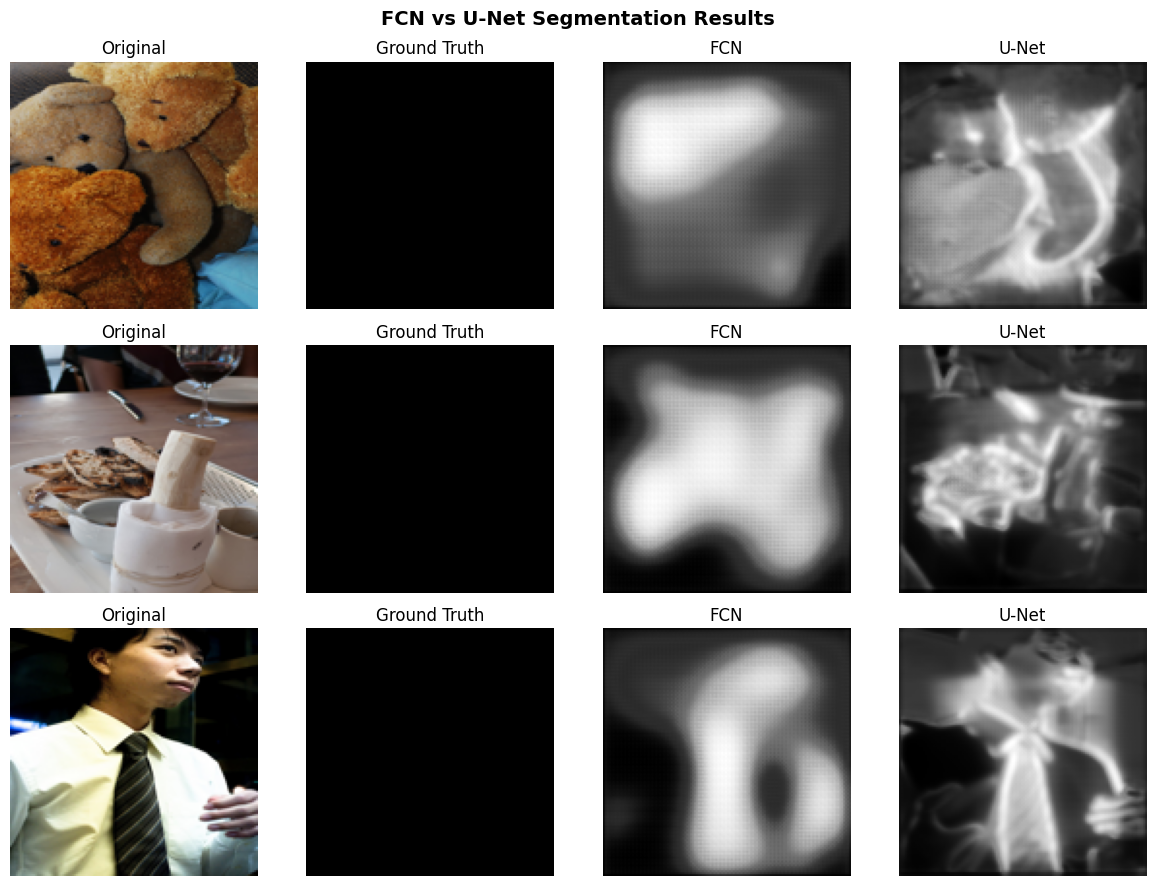

In [19]:
import matplotlib.pyplot as plt

# Get predictions
fcn_model.eval()
unet_model.eval()

val_images, val_masks = next(iter(val_loader))
val_images = val_images.to(device)

with torch.no_grad():
    fcn_preds = fcn_model(val_images)
    unet_preds = unet_model(val_images)

# Show 3 examples
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('FCN vs U-Net Segmentation Results', fontsize=14, fontweight='bold')

for i in range(3):
    # Original
    axes[i, 0].imshow(val_images[i].cpu().permute(1, 2, 0))
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    # Ground Truth
    axes[i, 1].imshow(val_masks[i].cpu().squeeze(), cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')

    # FCN
    axes[i, 2].imshow(fcn_preds[i].cpu().squeeze(), cmap='gray')
    axes[i, 2].set_title('FCN')
    axes[i, 2].axis('off')

    # U-Net
    axes[i, 3].imshow(unet_preds[i].cpu().squeeze(), cmap='gray')
    axes[i, 3].set_title('U-Net')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

